In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from scipy.stats import linregress

In [4]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

funds = pd.read_csv("../data/raw/01_fund_master.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [5]:
print(nav.shape)
print(funds.shape)
print(benchmark.shape)

(46000, 3)
(999, 26)
(2199, 3)


In [6]:
print(benchmark.columns.tolist())

['date', 'index_name', 'close_value']


In [8]:
benchmark['index_name'].unique()

<StringArray>
['NIFTY50', 'NIFTY100']
Length: 2, dtype: str

In [9]:
benchmark['date'] = pd.to_datetime(benchmark['date'])

benchmark_wide = benchmark.pivot(
    index='date',
    columns='index_name',
    values='close_value'
)

benchmark_wide.head()

index_name,NIFTY100,NIFTY50
date,,
2022-01-03,17778.24,17492.79
2022-01-04,17537.52,17689.64
2022-01-05,17607.73,17835.05
2022-01-06,17556.05,17878.51
2022-01-07,17664.02,17759.15


In [10]:
print(benchmark_wide.columns.tolist())

['NIFTY100', 'NIFTY50']


In [17]:
nifty100_returns = benchmark_wide['NIFTY100'].pct_change()

In [18]:
benchmark_wide['NIFTY50']

date
2022-01-03    17492.79
2022-01-04    17689.64
2022-01-05    17835.05
2022-01-06    17878.51
2022-01-07    17759.15
                ...   
2026-05-25    18186.57
2026-05-26    18418.36
2026-05-27    18523.57
2026-05-28    18421.08
2026-05-29    18517.65
Name: NIFTY50, Length: 1150, dtype: float64

In [19]:
benchmark_wide['NIFTY100']

date
2022-01-03    17778.24
2022-01-04    17537.52
2022-01-05    17607.73
2022-01-06    17556.05
2022-01-07    17664.02
                ...   
2026-05-25         NaN
2026-05-26         NaN
2026-05-27         NaN
2026-05-28         NaN
2026-05-29         NaN
Name: NIFTY100, Length: 1150, dtype: float64

In [21]:
print(nav['date'].min())
print(nav['date'].max())

print(benchmark['date'].min())
print(benchmark['date'].max())

2022-01-03
2026-05-29
2022-01-03 00:00:00
2026-05-29 00:00:00


In [23]:
import pandas as pd
import numpy as np

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

nav['date'] = pd.to_datetime(nav['date'])

In [24]:
nav_wide = nav.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

In [25]:
daily_returns = nav_wide.pct_change()

In [26]:
print(daily_returns.shape)
daily_returns.head()

(1150, 40)


amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714,...,0.018160,0.000243,0.001001,-0.005010,0.019318,0.015865,0.008378,-0.008592,0.000482,-0.010498
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913,...,-0.012304,0.000462,0.004250,-0.005184,-0.003939,-0.007660,0.015294,-0.006480,0.008670,-0.002593
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540,...,0.008509,0.000650,-0.003589,-0.002706,0.011892,-0.004709,0.000863,-0.003818,-0.013861,-0.008382
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793,...,-0.013477,0.000176,-0.002719,-0.012660,0.000515,0.007001,0.001173,-0.004069,0.004317,0.011680


In [27]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

benchmark['date'] = pd.to_datetime(
    benchmark['date']
)

benchmark_wide = benchmark.pivot(
    index='date',
    columns='index_name',
    values='close_value'
)

nifty100_returns = (
    benchmark_wide['NIFTY100']
    .pct_change()
)

In [28]:
print(daily_returns.shape)
print(nifty100_returns.shape)

(1150, 40)
(1150,)


In [29]:
code = daily_returns.columns[0]

fund_returns = daily_returns[code]

combined = pd.concat(
    [fund_returns, nifty100_returns],
    axis=1
).dropna()

combined.columns = [
    'fund',
    'benchmark'
]

print(combined.head())
print(combined.shape)

                fund  benchmark
date                           
2022-01-04 -0.010306  -0.013540
2022-01-05  0.012865   0.004003
2022-01-06 -0.011377  -0.002935
2022-01-07 -0.001210   0.006150
2022-01-10 -0.008639  -0.008351
(1048, 2)


In [30]:
from scipy.stats import linregress

alpha_beta_results = []

for code in daily_returns.columns:

    fund_returns = daily_returns[code]

    combined = pd.concat(
        [fund_returns, nifty100_returns],
        axis=1
    ).dropna()

    if len(combined) < 30:
        continue

    combined.columns = [
        'fund',
        'benchmark'
    ]

    slope, intercept, r_value, p_value, std_err = linregress(
        combined['benchmark'],
        combined['fund']
    )

    alpha_beta_results.append([
        code,
        intercept * 252,
        slope
    ])

In [31]:
alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        'amfi_code',
        'alpha',
        'beta'
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.063392,-0.067640
1,100025,0.048910,0.000372
2,100033,0.252929,0.008680
3,101206,0.168688,0.024941
4,101207,0.148319,-0.068960


In [32]:
print(alpha_beta_df.shape)

(40, 3)


In [33]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [34]:
print("cagr_df" in globals())
print("sharpe_df" in globals())
print("alpha_beta_df" in globals())
print("max_drawdown_df" in globals())

False
False
True
False


In [36]:
cagr_results = []

for code in nav['amfi_code'].unique():

    fund_data = nav[
        nav['amfi_code'] == code
    ].sort_values('date')

    if len(fund_data) < 252:
        continue

    start_nav = fund_data.iloc[0]['nav']
    end_nav = fund_data.iloc[-1]['nav']

    years = (
        (fund_data['date'].max()
         -
         fund_data['date'].min()
        ).days
    ) / 365

    cagr = (
        (end_nav/start_nav)
        **
        (1/years)
    ) - 1

    cagr_results.append([
        code,
        cagr
    ])

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        'amfi_code',
        'cagr'
    ]
)

cagr_df.head()
print(cagr_df.shape)

(40, 2)


In [37]:
rf = 0.065

sharpe_results = []

for code in daily_returns.columns:

    returns = daily_returns[code].dropna()

    annual_return = returns.mean() * 252

    volatility = returns.std()

    sharpe = (
        (annual_return - rf)
        /
        volatility
    ) * np.sqrt(252)

    sharpe_results.append([
        code,
        sharpe
    ])

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        'amfi_code',
        'sharpe'
    ]
)

sharpe_df.head()

,amfi_code,sharpe
0,100016,-50.782301
1,100025,-142.907888
2,100033,275.612083
3,101206,258.857759
4,101207,40.990514


In [38]:
print(sharpe_df.shape)

(40, 2)


In [39]:
max_dd_results = []

for code in nav_wide.columns:

    fund_nav = nav_wide[code].dropna()

    running_max = fund_nav.cummax()

    drawdown = (
        fund_nav /
        running_max
    ) - 1

    max_dd = drawdown.min()

    max_dd_results.append([
        code,
        max_dd
    ])

In [40]:
max_drawdown_df = pd.DataFrame(
    max_dd_results,
    columns=[
        'amfi_code',
        'max_drawdown'
    ]
)

max_drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [41]:
print(max_drawdown_df.shape)

(40, 2)


In [42]:
print(cagr_df.shape)
print(sharpe_df.shape)
print(alpha_beta_df.shape)
print(max_drawdown_df.shape)

(40, 2)
(40, 2)
(40, 3)
(40, 2)


In [44]:
scorecard = cagr_df.merge(
    sharpe_df,
    on='amfi_code'
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on='amfi_code'
)

scorecard = scorecard.merge(
    max_drawdown_df,
    on='amfi_code'
)

scorecard.head()

,amfi_code,cagr,sharpe,alpha,beta,max_drawdown
0,100016,0.026352,-50.782301,0.063392,-0.067640,-0.247344
1,100025,0.044551,-142.907888,0.048910,0.000372,-0.043083
2,100033,0.300997,275.612083,0.252929,0.008680,-0.162172
3,101206,0.235205,258.857759,0.168688,0.024941,-0.112916
4,101207,0.079331,40.990514,0.148319,-0.068960,-0.354469


In [45]:
scorecard['return_rank'] = scorecard['cagr'].rank(
    pct=True
)

scorecard['sharpe_rank'] = scorecard['sharpe'].rank(
    pct=True
)

scorecard['alpha_rank'] = scorecard['alpha'].rank(
    pct=True
)

In [46]:
scorecard['dd_rank'] = (
    scorecard['max_drawdown']
    .rank(pct=True, ascending=False)
)

In [47]:
funds = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

In [48]:
expense = funds[
    ['amfi_code', 'expense_ratio_pct']
]

In [49]:
scorecard = scorecard.merge(
    expense,
    on='amfi_code'
)

In [50]:
scorecard['expense_rank'] = (
    scorecard['expense_ratio_pct']
    .rank(
        pct=True,
        ascending=False
    )
)

In [51]:
scorecard['score'] = (
    0.30 * scorecard['return_rank']
    +
    0.25 * scorecard['sharpe_rank']
    +
    0.20 * scorecard['alpha_rank']
    +
    0.15 * scorecard['expense_rank']
    +
    0.10 * scorecard['dd_rank']
) * 100

In [52]:
scorecard = scorecard.sort_values(
    'score',
    ascending=False
)

In [53]:
scorecard[
    ['amfi_code', 'score']
].head(10)

,amfi_code,score
25,120505,86.5000
21,119598,82.1250
39,149324,80.6875
30,120843,80.0000
34,148567,79.2500
2,100033,77.2500
16,119094,75.7500
36,148569,73.9375
38,149323,70.7500
24,120504,70.2500


In [54]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [55]:
scorecard.shape

(40, 13)

In [57]:
rf = 0.065

sortino_results = []

for code in daily_returns.columns:

    returns = daily_returns[code].dropna()

    annual_return = returns.mean() * 252

    downside = returns[returns < 0]

    downside_std = downside.std()

    if downside_std == 0 or np.isnan(downside_std):
        continue

    sortino = (
        (annual_return - rf)
        /
        downside_std
    ) * np.sqrt(252)

    sortino_results.append([
        code,
        sortino
    ])

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        'amfi_code',
        'sortino_ratio'
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-88.463960
1,100025,-237.338952
2,100033,460.941758
3,101206,453.489844
4,101207,69.714237


In [58]:
print(sortino_df.shape)

(40, 2)


In [59]:
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

In [60]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [61]:
benchmark['index_name'].unique()

<StringArray>
['NIFTY50', 'NIFTY100']
Length: 2, dtype: str

In [62]:
benchmark.shape

(2199, 3)

In [63]:
benchmark['date'] = pd.to_datetime(benchmark['date'])

nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty100 = nifty100.sort_values('date')

nifty100['return'] = (
    nifty100['close_value']
    .pct_change()
)

nifty100_returns = nifty100.set_index(
    'date'
)['return']

print(nifty100_returns.shape)
nifty100_returns.head()

(1049,)


date
2022-01-03         NaN
2022-01-04   -0.013540
2022-01-05    0.004003
2022-01-06   -0.002935
2022-01-07    0.006150
Name: return, dtype: float64

In [64]:
print(nifty100_returns.isna().sum())

1


In [65]:
tracking_results = []

for code in daily_returns.columns:

    fund_returns = daily_returns[code].dropna()

    combined = pd.concat(
        [fund_returns, nifty100_returns],
        axis=1,
        join='inner'
    )

    combined.columns = [
        'fund_return',
        'benchmark_return'
    ]

    tracking_error = (
        (combined['fund_return']
         - combined['benchmark_return'])
        .std()
        * np.sqrt(252)
    )

    tracking_results.append([
        code,
        tracking_error
    ])

tracking_error_df = pd.DataFrame(
    tracking_results,
    columns=[
        'amfi_code',
        'tracking_error'
    ]
)

tracking_error_df.head()

,amfi_code,tracking_error
0,100016,0.199431
1,100025,0.134874
2,100033,0.229616
3,101206,0.191729
4,101207,0.292230


In [66]:
print(tracking_error_df.shape)

(40, 2)


In [67]:
top5 = scorecard.head(5)['amfi_code'].tolist()

print(top5)

[120505, 119598, 149324, 120843, 148567]


In [68]:
top5_nav = nav[
    nav['amfi_code'].isin(top5)
].copy()

top5_nav = top5_nav.sort_values(
    ['amfi_code', 'date']
)

top5_nav['normalized_nav'] = (
    top5_nav.groupby('amfi_code')['nav']
    .transform(lambda x: x / x.iloc[0] * 100)
)

top5_nav.head()

,amfi_code,date,nav,normalized_nav
24150,119598,2022-01-03,89.8738,100.000000
24151,119598,2022-01-04,88.5495,98.526489
24152,119598,2022-01-05,88.0925,98.017999
24153,119598,2022-01-06,88.5175,98.490884
24154,119598,2022-01-07,91.4235,101.724307


In [69]:
nifty50 = benchmark[
    benchmark['index_name'] == 'NIFTY50'
].copy()

nifty50 = nifty50.sort_values('date')

nifty50['normalized'] = (
    nifty50['close_value']
    / nifty50['close_value'].iloc[0]
    * 100
)

In [70]:
nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty100 = nifty100.sort_values('date')

nifty100['normalized'] = (
    nifty100['close_value']
    / nifty100['close_value'].iloc[0]
    * 100
)

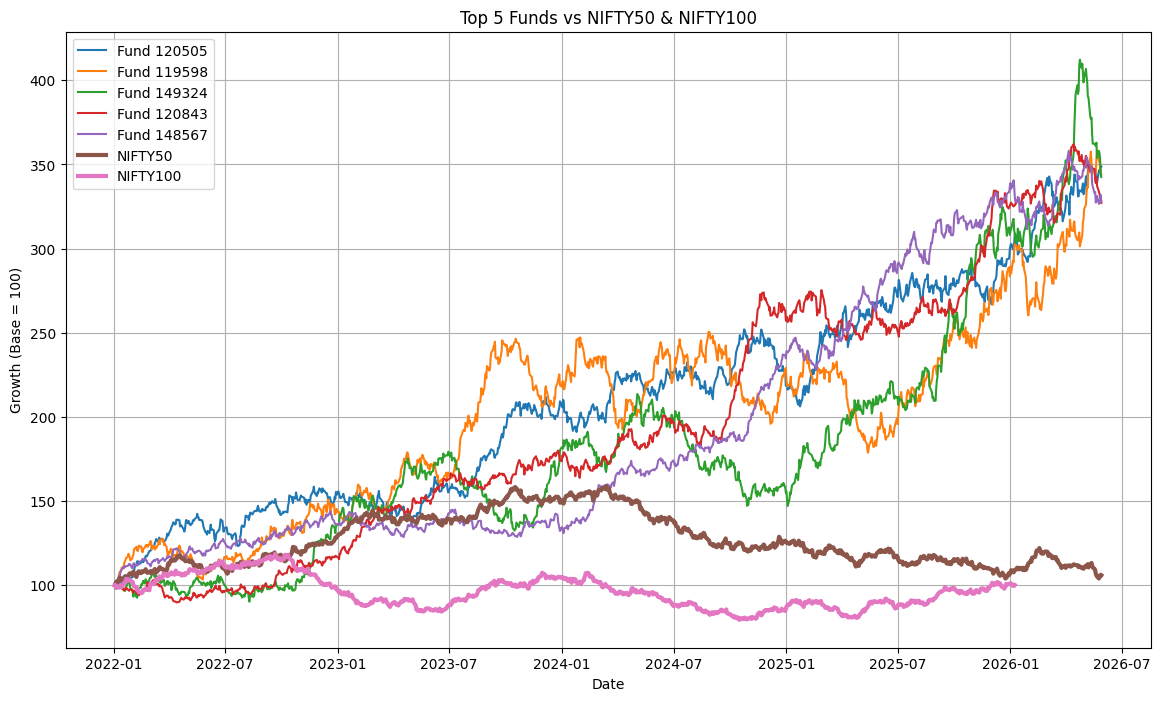

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

for code in top5:
    
    temp = top5_nav[
        top5_nav['amfi_code'] == code
    ]
    
    plt.plot(
        temp['date'],
        temp['normalized_nav'],
        label=f'Fund {code}'
    )

plt.plot(
    nifty50['date'],
    nifty50['normalized'],
    linewidth=3,
    label='NIFTY50'
)

plt.plot(
    nifty100['date'],
    nifty100['normalized'],
    linewidth=3,
    label='NIFTY100'
)

plt.title(
    'Top 5 Funds vs NIFTY50 & NIFTY100'
)

plt.xlabel('Date')
plt.ylabel('Growth (Base = 100)')

plt.legend()

plt.grid(True)

plt.savefig(
    '../charts/benchmark_comparison.png',
    bbox_inches='tight'
)

plt.show()

In [72]:
tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

In [73]:
import os

print(os.listdir("../reports"))
print(os.listdir("../charts"))

['alpha_beta.csv', 'data_dictionary.md', 'fund_scorecard.csv', 'sortino_ratio.csv', 'tracking_error.csv']
['age_distribution.png', 'age_group_boxplot.html', 'age_group_distribution.html', 'aum_growth.png', 'benchmark_comparison.png', 'category_heatmap.png', 'folio_growth.html', 'folio_growth.png', 'gender_distribution.html', 'gender_distribution.png', 'nav_correlation_matrix.png', 'nav_trend.png', 'sector_allocation.png', 'sector_allocation_donut.html', 'sip_inflow.png', 'sip_trend.html', 'state_investment.html', 'state_investment.png', 't30_b30_distribution.html', 't30_b30_distribution.png', 'top_states.png']


In [74]:
os.listdir("../reports")

['alpha_beta.csv',
 'data_dictionary.md',
 'fund_scorecard.csv',
 'sortino_ratio.csv',
 'tracking_error.csv']

In [75]:
import os
print(os.listdir("../charts"))

['age_distribution.png', 'age_group_boxplot.html', 'age_group_distribution.html', 'aum_growth.png', 'benchmark_comparison.png', 'category_heatmap.png', 'folio_growth.html', 'folio_growth.png', 'gender_distribution.html', 'gender_distribution.png', 'nav_correlation_matrix.png', 'nav_trend.png', 'sector_allocation.png', 'sector_allocation_donut.html', 'sip_inflow.png', 'sip_trend.html', 'state_investment.html', 'state_investment.png', 't30_b30_distribution.html', 't30_b30_distribution.png', 'top_states.png']


In [76]:
import os
print("cagr_table.csv" in os.listdir("../reports"))

False


In [77]:
cagr_df.to_csv(
    "../reports/cagr_table.csv",
    index=False
)

In [78]:
import os

print(os.listdir("../reports"))

['alpha_beta.csv', 'cagr_table.csv', 'data_dictionary.md', 'fund_scorecard.csv', 'sortino_ratio.csv', 'tracking_error.csv']


In [79]:
print(os.listdir("../charts"))

['age_distribution.png', 'age_group_boxplot.html', 'age_group_distribution.html', 'aum_growth.png', 'benchmark_comparison.png', 'category_heatmap.png', 'folio_growth.html', 'folio_growth.png', 'gender_distribution.html', 'gender_distribution.png', 'nav_correlation_matrix.png', 'nav_trend.png', 'sector_allocation.png', 'sector_allocation_donut.html', 'sip_inflow.png', 'sip_trend.html', 'state_investment.html', 'state_investment.png', 't30_b30_distribution.html', 't30_b30_distribution.png', 'top_states.png']


In [80]:
os.listdir("../charts")

['age_distribution.png',
 'age_group_boxplot.html',
 'age_group_distribution.html',
 'aum_growth.png',
 'benchmark_comparison.png',
 'category_heatmap.png',
 'folio_growth.html',
 'folio_growth.png',
 'gender_distribution.html',
 'gender_distribution.png',
 'nav_correlation_matrix.png',
 'nav_trend.png',
 'sector_allocation.png',
 'sector_allocation_donut.html',
 'sip_inflow.png',
 'sip_trend.html',
 'state_investment.html',
 'state_investment.png',
 't30_b30_distribution.html',
 't30_b30_distribution.png',
 'top_states.png']

SyntaxError: invalid syntax (548612153.py, line 1)